## Utils

In [2]:
def prepend_zeros(example, num_metadata_tokens=6):
    # Convert tensor to list for manipulation
    import torch

    expressions = example["expressions"].tolist()
    zeros = [0.0] * num_metadata_tokens
    expressions = zeros + expressions

    # Convert back to tensor if you're using HF with torch format
    example["expressions"] = torch.tensor(expressions, dtype=torch.float)
    return example

def move_cls_to_front(example, cls_token_id=60695):
    genes = example["genes"].tolist()
    
    import torch

    if cls_token_id in genes:
        genes.remove(cls_token_id)
        genes = [cls_token_id] + genes

    example["genes"] = torch.tensor(genes, dtype=torch.long)
    return example

def compute_pca_embeddings(
    adata,
    n_components=50,
    latent_key="X_pca",
    normalize=True,
    log1p=True,
    scale=True,
    zero_center=True,
    svd_solver=None,
    random_state=0,
):
    """
    Compute PCA embeddings on AnnData and store them in adata.obsm[latent_key].

    Parameters:
    - adata: AnnData object (must contain data in adata.X or specified layer).
    - layer: Layer name to use for PCA (default: None → adata.X).
    - n_components: Number of principal components to compute.
    - latent_key: Key under adata.obsm to store PCA output.
    - normalize: If True, normalize per cell (scanpy.pp.normalize_total).
    - log1p: If True, apply log1p transformation.
    - scale: If True, scale data (zero-mean, unit variance).
    - zero_center: Passed to scanpy.pp.pca; if True, center variables (regular PCA), else applies SVD.
    - svd_solver: Optional solver choice for PCA (default: None → auto).
    - random_state: Random seed for reproducibility.

    Returns:
    - Updated AnnData object with PCA embeddings stored in adata.obsm[latent_key].
    """
    import scanpy as sc

    # Work on a copy to avoid modifying adata.X in place
    adata_copy = adata.copy()

    # Normalize, log-transform, and scale as requested
    if normalize:
        sc.pp.normalize_total(adata_copy)
    if log1p:
        sc.pp.log1p(adata_copy)
    if scale:
        sc.pp.scale(adata_copy)

    # Compute PCA using the specified data source (adata.X or the layer)
    sc.pp.pca(
        adata_copy,
        n_comps=n_components,
        zero_center=zero_center,
        svd_solver=svd_solver,
        random_state=random_state,
    )

    # Store the result in the original AnnData object's obsm
    adata.obsm[latent_key] = adata_copy.obsm["X_pca"][:, :n_components]

    return adata

def compute_scvi_embeddings(
    adata,
    batch_key="dataset_id",
    n_layers=2,
    n_latent=50,
    gene_likelihood="nb"
):
    """
    Compute and store scVI latent embeddings in adata.obsm["X_scvi"],
    assuming raw counts are in adata.X.

    Parameters:
    - adata: AnnData object with raw count data in adata.X.
    - batch_key: Key in adata.obs indicating batch labels (default: "dataset_id").
    - n_layers: Number of hidden layers in encoder/decoder.
    - n_latent: Dimensionality of the latent space.
    - gene_likelihood: Likelihood model to use ("nb", "zinb", etc.).

    Returns:
    - Updated AnnData object with latent embeddings in .obsm["X_scvi"].
    """
    import scvi

    scvi.model.SCVI.setup_anndata(adata, batch_key=batch_key)
    model = scvi.model.SCVI(
        adata,
        n_layers=n_layers,
        n_latent=n_latent,
        gene_likelihood=gene_likelihood
    )
    model.train()
    adata.obsm["X_scvi"] = model.get_latent_representation()
    return adata

def compute_scgpt_embeddings(
    data_path: str,
    model_dir: str,
    gene_col: str = "feature_name",
    batch_size: int = 128,
    return_new_adata: bool = False,
    save_path: str = None
):
    """
    Computes SCGPT embeddings for a given h5ad file.

    Parameters:
        data_path (str): Path to the input .h5ad file.
        model_dir (str): Path to the pretrained SCGPT model directory.
        gene_col (str): Column name for gene features.
        batch_size (int): Batch size to use for embedding.
        return_new_adata (bool): Whether to return a new AnnData object.

    Returns:
        AnnData: The embedded AnnData object (modified in-place if return_new_adata=False).
    """

    from scgpt.tasks import embed_data
    import scanpy as sc
    adata = sc.read_h5ad(data_path)
    adata = embed_data(
        adata_or_file=adata,
        model_dir=model_dir,
        gene_col=gene_col,
        batch_size=batch_size,
        return_new_adata=return_new_adata,
    )
    if save_path:
        adata.write(save_path)
        print(f"Embedded data saved to {save_path}")
    return adata

def compute_umap_and_leiden(adata, use_rep="custom", umap_key="custom", leiden_key="custom", metric="euclidean", n_neighbors=15, min_dist=0.3, random_state=0, resolution=1.0):
    """
    Compute neighbors and UMAP for a given embedding and store in adata.obsm[umap_key].

    Parameters:
    - adata: AnnData object with embeddings in adata.obsm[use_rep].
    - use_rep: Key in adata.obsm to use as input for computing neighbors.
    - umap_key: Key in adata.obsm to store UMAP coordinates.
    - n_neighbors: Number of neighbors for the KNN graph (default: 15).
    - min_dist: Controls how tightly UMAP packs points together (default: 0.3).
    - random_state: Random seed for reproducibility.

    Returns:
    - Updated AnnData object with UMAP stored in adata.obsm[umap_key].
    """
    import scanpy as sc

    # Compute neighbors from the specified representation
    sc.pp.neighbors(adata, use_rep=f"X_{use_rep}", n_neighbors=n_neighbors, metric=metric, random_state=0)

    # Compute UMAP
    sc.tl.umap(adata, min_dist=min_dist, random_state=random_state)

    # Save UMAP to a custom key to avoid overwriting
    adata.obsm[f"X_umap_{umap_key}"] = adata.obsm["X_umap"]

    # Run Leiden clustering
    sc.tl.leiden(
        adata,
        key_added=f"leiden_{leiden_key}",
        resolution=resolution,
    )

    return adata

def compute_clustering_metrics(adata, embedding_key='X_umap', cluster_key='leiden', label_key='cell_type'):
    """
    Compute Silhouette Score, ARI, and NMI for a given AnnData object.
    
    Parameters:
        adata (AnnData): Annotated data object with embedding and clustering.
        embedding_key (str): Key in adata.obsm for the 2D embedding (e.g., UMAP).
        cluster_key (str): Key in adata.obs for clustering labels (e.g., leiden).
        label_key (str): Key in adata.obs for ground truth labels (e.g., cell type).
        
    Returns:
        dict: Dictionary with silhouette, ARI, and NMI scores.
    """
    from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

    embedding = adata.obsm[f"X_{embedding_key}"]
    cluster_labels = adata.obs[f"leiden_{cluster_key}"].values
    true_labels = adata.obs[label_key].values

    # Silhouette Score: only makes sense if more than 1 cluster
    if len(set(cluster_labels)) > 1:
        sil_score = silhouette_score(embedding, cluster_labels)
    else:
        sil_score = float('nan')

    ari = adjusted_rand_score(true_labels, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)

    return {
        'silhouette': sil_score,
        'ARI': ari,
        'NMI': nmi
    }

## scImmune - Embedding Generation

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch.utils.data import DataLoader
import tqdm

# --- your modules ---
from tokenizer import ScImmuneTokenizer
from config import ScImmuneConfig
from model import ScImmuneModel
from collator import ScImmuneDataCollator

# =======================
# User settings
# =======================
H5AD_PATH = "../data/inference/covid_cells_chunk0.h5ad"
MODEL_DIR = "final"     # folder with model.safetensors + config.json
VOCAB_FILE = "vocab_with_metadata.json"
NUM_META = 6
SCALE_FACTOR = 100.0                        # must match training
BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Map obs fields -> token tag used in your vocab
# (Adjust the right-hand side strings so they exactly match your vocab’s token prefixes)

FIELD_TO_TAG = {
    "cell_type_ontology_term_id":           "cell_type",
    "self_reported_ethnicity_ontology_term_id": "self_reported_ethnicity",
    "tissue_general_ontology_term_id":      "tissue_general",
    "development_stage_ontology_term_id":   "development_stage",
    "sex_ontology_term_id":                 "sex",
    "disease_ontology_term_id":             "disease",
}
assert len(FIELD_TO_TAG) == NUM_META, "NUM_META must match the number of metadata fields."

# =======================
# Load data & model
# =======================
adata = sc.read_h5ad(H5AD_PATH)

for colname in list(adata.obs.columns):
    if pd.api.types.is_categorical_dtype(adata.obs[colname]):
        adata.obs[colname] = adata.obs[colname].cat.remove_unused_categories()

/tmp/ipykernel_2095529/1607599859.py:44: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[colname]):


In [5]:
adata.obs["disease_ontology_term_id"] = adata.obs["disease_ontology_term_id"].astype(str)
adata.obs.loc[adata.obs["disease"] == "normal", "disease_ontology_term_id"] = "DOID:4"

In [6]:
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else np.asarray(adata.X)
gene_symbols = np.asarray(adata.var.feature_name)

gene_symbols

array(['LINC01409', 'NOC2L', 'PERM1', ..., 'LGALS17A', 'FLJ43315', 'XGY2'],
      dtype=object)

In [7]:
tok = ScImmuneTokenizer(vocab_file=VOCAB_FILE)
cfg = ScImmuneConfig.from_pretrained(MODEL_DIR)
model = ScImmuneModel.from_pretrained(MODEL_DIR, config=cfg).to(DEVICE).eval()

cls_id = tok.convert_tokens_to_ids(tok.cls_token)
unk_token = tok.unk_token
unk_id = tok.convert_tokens_to_ids(unk_token)

In [11]:
adata.obs.dataset_id.value_counts()

dataset_id
01ad3cd7-3929-4654-84c0-6db05bd5fd59    34036
9f222629-9e39-47d0-b83f-e08d610c7479    10468
59b69042-47c2-47fd-ad03-d21beb99818f     8714
9dbab10c-118d-496b-966a-67f1763a6b7d     5998
7f7faf6b-f11d-4f07-bc1c-188a4472748d     2667
c7775e88-49bf-4ba2-a03b-93f00447c958     2536
7b55fe5c-d5c8-48e0-a1a3-54c5b9074f3f     2397
7c497c66-c2e2-4291-8b96-339e5e65f314     1514
2ac76f1b-43ef-4271-8686-2f165570989f      946
5e717147-0f75-4de1-8bd2-6fda01b8d75f      224
de2c780c-1747-40bd-9ccf-9588ec186cee      161
db59611b-42de-4035-93aa-1ed39f38b467       47
eeacb0c1-2217-4cf6-b8ce-1f0fedf1b569       35
881fe679-c6e0-45a3-9427-c4e81be6921f       34
cab0bc48-744c-461b-aaf4-7bf2cb7af00d       31
c874f155-9bf9-4928-b821-f52c876b3e48       30
ed9e9f96-4f08-49d2-bef5-b2c29adf3edc       29
79ef1959-a6b4-4cac-82ca-30feaec48df1       27
50eb1e23-b8d4-4f76-a184-44e5541fa05a       25
ea786a06-5855-48b7-80d7-0313a21a2044       22
84230ea4-998d-4aa8-8456-81dd54ce23af       22
8a554710-08bc-4005-87cd

In [19]:
ref_lung_adata = adata[adata.obs.dataset_id == "9f222629-9e39-47d0-b83f-e08d610c7479"]
query_blood_adata = adata[adata.obs.dataset_id == "59b69042-47c2-47fd-ad03-d21beb99818f"]

In [86]:
import tqdm
metadata_fields = [
                    "cell_type_ontology_term_id",
                    "self_reported_ethnicity_ontology_term_id", 
                    "tissue_general_ontology_term_id",
                    "development_stage_ontology_term_id",
                    "sex_ontology_term_id",
                    "disease_ontology_term_id"
]

gene_names = query_blood_adata.var.feature_name.values # get gene names

tokenized_input_ids = []
tokenized_values = []

for i in range(query_blood_adata.n_obs):
    
    # 1. Get dense expression vector
    row = query_blood_adata.X[i]
    if not isinstance(row, np.ndarray):
        row = row.toarray().squeeze()

    # 2. Get metadata tokens
    obs_row = query_blood_adata.obs.iloc[i]
    metadata_tokens = []
    for field in metadata_fields:
        val = obs_row.get(field)
        if isinstance(val, str) and val != "NA" and "=" not in val:
            token = f"<{field.split('_ontology_term_id')[0]}={val}>"
            metadata_tokens.append(token)

    # 3. Tokenize
    tokenized = tok.tokenize_cell_batch(
        data=np.expand_dims(row, axis=0),
        gene_ids=gene_names,
        metadata_tokens=metadata_tokens,
        append_cls=True,
        include_zero_gene=False
    )
    
    input_ids, values = tokenized[0]
    tokenized_input_ids.append(input_ids)
    tokenized_values.append(values)

In [87]:
from datasets import Dataset
import torch

# Padding and truncation happen in DataCollator, not here
hf_dataset = Dataset.from_dict({
    "genes": tokenized_input_ids,
    "expressions": tokenized_values
})

hf_dataset.set_format(type="torch", columns=["genes", "expressions"])

hf_dataset = hf_dataset.map(prepend_zeros)
hf_dataset = hf_dataset.map(move_cls_to_front)

Map: 100%|██████████| 8714/8714 [00:03<00:00, 2564.62 examples/s]


In [88]:
hf_dataset["genes"][0][:10]

tensor([60695, 60766, 60926, 60942, 61011, 61046, 60697, 34797,  1316,  2921])

In [89]:
### METADATA TOKENIZATION STRATEGY

hf_dataset = hf_dataset.map(
    lambda example: {
        'genes': [
            60697 if i in [3] else val
            for i, val in enumerate(example['genes'].tolist())
        ]
    }
)

Map: 100%|██████████| 8714/8714 [00:05<00:00, 1641.19 examples/s]


In [90]:
import torch.nn.functional as F

# =======================
# Collator for PCPT inference
# =======================
# We already scaled values; we just need padding + attention_mask.
collator = ScImmuneDataCollator(
    do_padding=True,
    pad_token_id=tok.pad_token_id,
    pad_value=-2,
    do_mlm=False,
    do_binning=False,
    mlm_probability=0.0,
    max_length=getattr(cfg, "max_seq_len", 2000),
    sampling=False,
    keep_first_n_tokens= 1 + NUM_META,
    data_style="pcpt",
    scale_factor=100.0,
)
# # If your collator tries to scale on pcpt, disable:
# setattr(collator, "scale_factor")

dl = DataLoader(hf_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

# =======================
# Embed
# =======================
embs = []
with torch.no_grad():
    for batch in dl:
        # collator._call_pcpt likely returns {"gene","expr"} in your codebase.
        # If you already patched it to return ("input_ids","values","attention_mask"), adapt here.
        input_ids = batch.get("input_ids", batch.get("gene")).to(DEVICE)
        values    = batch.get("values",    batch.get("expr")).to(DEVICE)

        # HF attention mask: 1=keep, 0=pad
        attention_mask = (input_ids != tok.pad_token_id).long().to(DEVICE)

        out = model(
            input_ids=input_ids,
            values=values,
            attention_mask=attention_mask,
            generative_training=False,  # force perceptual path
        )
        embs.append(out["cell_emb"].detach().cpu())

embs = torch.cat(embs, dim=0)  # shape: (n_cells, d)

# # L2-normalize per cell
embs = F.normalize(embs, p=2, dim=1)  # keeps magnitude=1

In [94]:
ref_lung_adata.obsm

AxisArrays with keys: X_pca, X_scGPT, X_scgpt, X_scimmune, X_scvi, X_umap, X_umap_pca, X_umap_scgpt, X_umap_scimmune, X_umap_scvi, X_scimmune_all_unk, X_scimmune_drop_tissue

In [96]:
query_blood_adata.obsm["X_scimmune_all_unk"] = query_blood_adata.obsm["X_scimmune_unk"]

In [105]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

def _knn_weighted_vote(X_ref, y_ref, X_q, k=20, metric="cosine", temperature=1.0):
    """
    L2-normalize, build KNN on ref, weighted vote on query.
    metric: "cosine" (recommended) or "euclidean" (on L2-normalized X it's similar).
    """
    # L2-normalize rows (works well for high-dim embeddings)
    Xr = X_ref / (np.linalg.norm(X_ref, axis=1, keepdims=True) + 1e-8)
    Xq = X_q   / (np.linalg.norm(X_q,   axis=1, keepdims=True) + 1e-8)

    # Cosine distance in sklearn = 1 - cosine_similarity (still fine for KNN)
    nn = NearestNeighbors(n_neighbors=min(k, len(Xr)), metric=metric, n_jobs=-1)
    nn.fit(Xr)
    dists, idxs = nn.kneighbors(Xq, return_distance=True)   # shapes: (Nq, k)

    # convert distances to weights; smaller dist => higher weight
    # for cosine dist in [0,2], this still works; temperature softens/sharpens
    weights = np.exp(-(dists / (dists.std(axis=1, keepdims=True) + 1e-8)) / max(temperature, 1e-6))

    # weighted majority vote
    y_pred = []
    for wi, ii in zip(weights, idxs):
        labels_i = y_ref[ii]
        # aggregate weights per class
        uniq, inv = np.unique(labels_i, return_inverse=True)
        w_per_class = np.zeros(len(uniq), dtype=float)
        np.add.at(w_per_class, inv, wi)
        y_pred.append(uniq[w_per_class.argmax()])
    return np.array(y_pred, dtype=y_ref.dtype)

def map_and_score_overlap(X_ref, y_ref, X_q, y_q, k=20, metric="cosine", weighted=True):
    """
    Keep only overlapping classes in BOTH ref and query before KNN.
    Returns: (metrics_dict, y_pred_on_overlap_query)
    """
    # 1) overlap set
    overlap = np.intersect1d(np.unique(y_ref), np.unique(y_q))
    if overlap.size == 0:
        return {"acc": 0.0, "bacc": 0.0, "f1_macro": 0.0}, np.array([])

    keep_ref = np.isin(y_ref, overlap)
    keep_q   = np.isin(y_q,   overlap)

    Xr, yr = X_ref[keep_ref], y_ref[keep_ref]
    Xq, yq = X_q[keep_q],     y_q[keep_q]

    # 2) predict on the filtered query
    if weighted:
        y_pred = _knn_weighted_vote(Xr, yr, Xq, k=k, metric=metric)
    else:
        nn = NearestNeighbors(n_neighbors=min(k, len(Xr)), metric=metric, n_jobs=-1)
        nn.fit(Xr / (np.linalg.norm(Xr, axis=1, keepdims=True) + 1e-8))
        idxs = nn.kneighbors(Xq / (np.linalg.norm(Xq, axis=1, keepdims=True) + 1e-8),
                             return_distance=False)
        # unweighted majority
        y_pred = np.array([np.bincount(yr[idx], minlength=len(overlap)).argmax() for idx in idxs])
        # map back to class names if yr is strings
        if isinstance(yr[0], str):
            # rebuild class list in a stable order
            classes = np.array(sorted(overlap.tolist()))
            y_pred = classes[y_pred]

    # 3) metrics on the filtered subset
    acc   = accuracy_score(yq, y_pred)
    bacc  = balanced_accuracy_score(yq, y_pred)
    f1mac = f1_score(yq, y_pred, average="macro")
    metrics = {"acc": acc, "bacc": bacc, "f1_macro": f1mac}

    # (Optional: you can also return keep_ref/keep_q if you need coverage info)
    return metrics, y_pred

In [106]:
EMB_KEYS = [
    "X_scimmune",
    "X_scimmune_all_unk",
    "X_scimmune_drop_tissue",
]

def run_unconstrained_all(adata_ref, adata_q, label_col="cell_type", k=20, metric="cosine"):
    y_ref = adata_ref.obs[label_col].astype(str).values
    y_q   = adata_q.obs[label_col].astype(str).values

    results = {}
    for key in EMB_KEYS:
        X_ref = np.asarray(adata_ref.obsm[key])
        X_q   = np.asarray(adata_q.obsm[key])
        metrics, y_pred = map_and_score_overlap(X_ref, y_ref, X_q, y_q, k=k, metric=metric, weighted=True)
        results[key] = {"metrics": metrics, "y_pred": y_pred}
        print(f"[Overlap-only] {key}: {metrics}")
    return results

unconstrained_results = run_unconstrained_all(ref_lung_adata, query_blood_adata)

[Overlap-only] X_scimmune: {'acc': 0.8276273885350318, 'bacc': 0.7335836977240163, 'f1_macro': 0.7360033551060853}
[Overlap-only] X_scimmune_all_unk: {'acc': 0.8268312101910829, 'bacc': 0.7323759682554173, 'f1_macro': 0.7346532014545337}
[Overlap-only] X_scimmune_drop_tissue: {'acc': 0.8276273885350318, 'bacc': 0.7335836977240163, 'f1_macro': 0.7360033551060853}


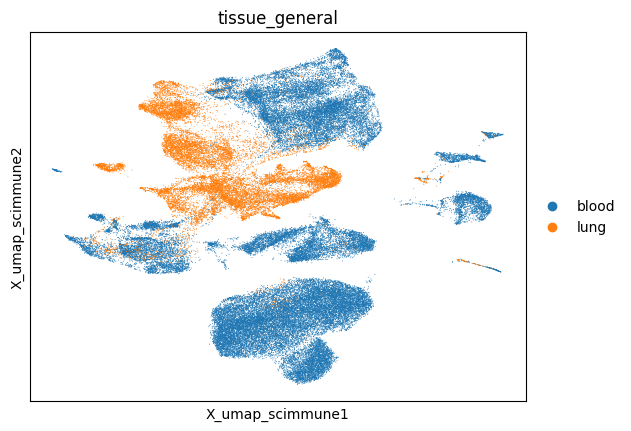

In [111]:
sc.pl.embedding(adata, basis="X_umap_scimmune", color="tissue_general")